In [1]:
# import all the libraries
import pandas as pd
import numpy as np
import json
import re
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# load the data
weather = pd.read_csv(r'C:\Users\manas\OneDrive\Documents\weather_observations.csv')
calendar= pd.read_csv(r'C:\Users\manas\OneDrive\Documents\calendar_events.csv')
traffic= pd.read_csv(r'C:\Users\manas\OneDrive\Documents\traffic_sensor_log.csv')

In [3]:
#  Convert date columns to datetime (weather uses DD/MM/YYYY, calendar/traffic use YYYY-MM-DD)
weather['date'] = pd.to_datetime(weather['date'], format='%d/%m/%Y')
calendar['date'] = pd.to_datetime(calendar['date'], format='%Y-%m-%d')
traffic['date'] = pd.to_datetime(traffic['date'], format='%Y-%m-%d')

In [4]:
# Combine date + time into a full timestamp for weather and traffic
weather['timestamp'] = pd.to_datetime(weather['date'].astype(str) + ' ' + weather['time'])
traffic['timestamp'] = pd.to_datetime(traffic['date'].astype(str) + ' ' + traffic['time'])

In [5]:
# check the data is loaded
print("Weather shape:", weather.shape)
print("Calendar shape:", calendar.shape)
print("Traffic shape:", traffic.shape)

print("\nWeather preview:")
print(weather.head())

print("\nCalendar preview:")
print(calendar.head())

print("\nTraffic preview:")
print(traffic.head())

Weather shape: (10872, 8)
Calendar shape: (151, 6)
Traffic shape: (178468, 18)

Weather preview:
  station_id       date   time weather_condition  temperature  rainfall  \
0   WS-NORTH 2025-01-01  00:00             Clear         12.7       0.0   
1   WS-NORTH 2025-01-01  01:00             Clear          8.8       0.0   
2   WS-NORTH 2025-01-01  02:00             clear          9.8       0.0   
3   WS-NORTH 2025-01-01  03:00             Clear          9.4       0.0   
4   WS-NORTH 2025-01-01  04:00             clear          9.0       0.0   

   visibility           timestamp  
0     10000.0 2025-01-01 00:00:00  
1     10000.0 2025-01-01 01:00:00  
2     10000.0 2025-01-01 02:00:00  
3     10000.0 2025-01-01 03:00:00  
4         NaN 2025-01-01 04:00:00  

Calendar preview:
        date  public_holiday    holiday_name  event_flag event_name  \
0 2025-01-01               1  New Year's Day           0        NaN   
1 2025-01-02               0             NaN           0        NaN   
2 20

In [6]:
# Clean & consolidate weather conditions
weather['weather_condition_clean'] = weather['weather_condition'].str.strip().str.lower()
weather['weather_condition_clean'] = weather['weather_condition_clean'].replace({'rainy': 'rain', 'foggy': 'fog'})
weather_counts = weather['weather_condition_clean'].value_counts()

# Congestion levels
congestion_counts = traffic['congestion_level'].value_counts(dropna=True)


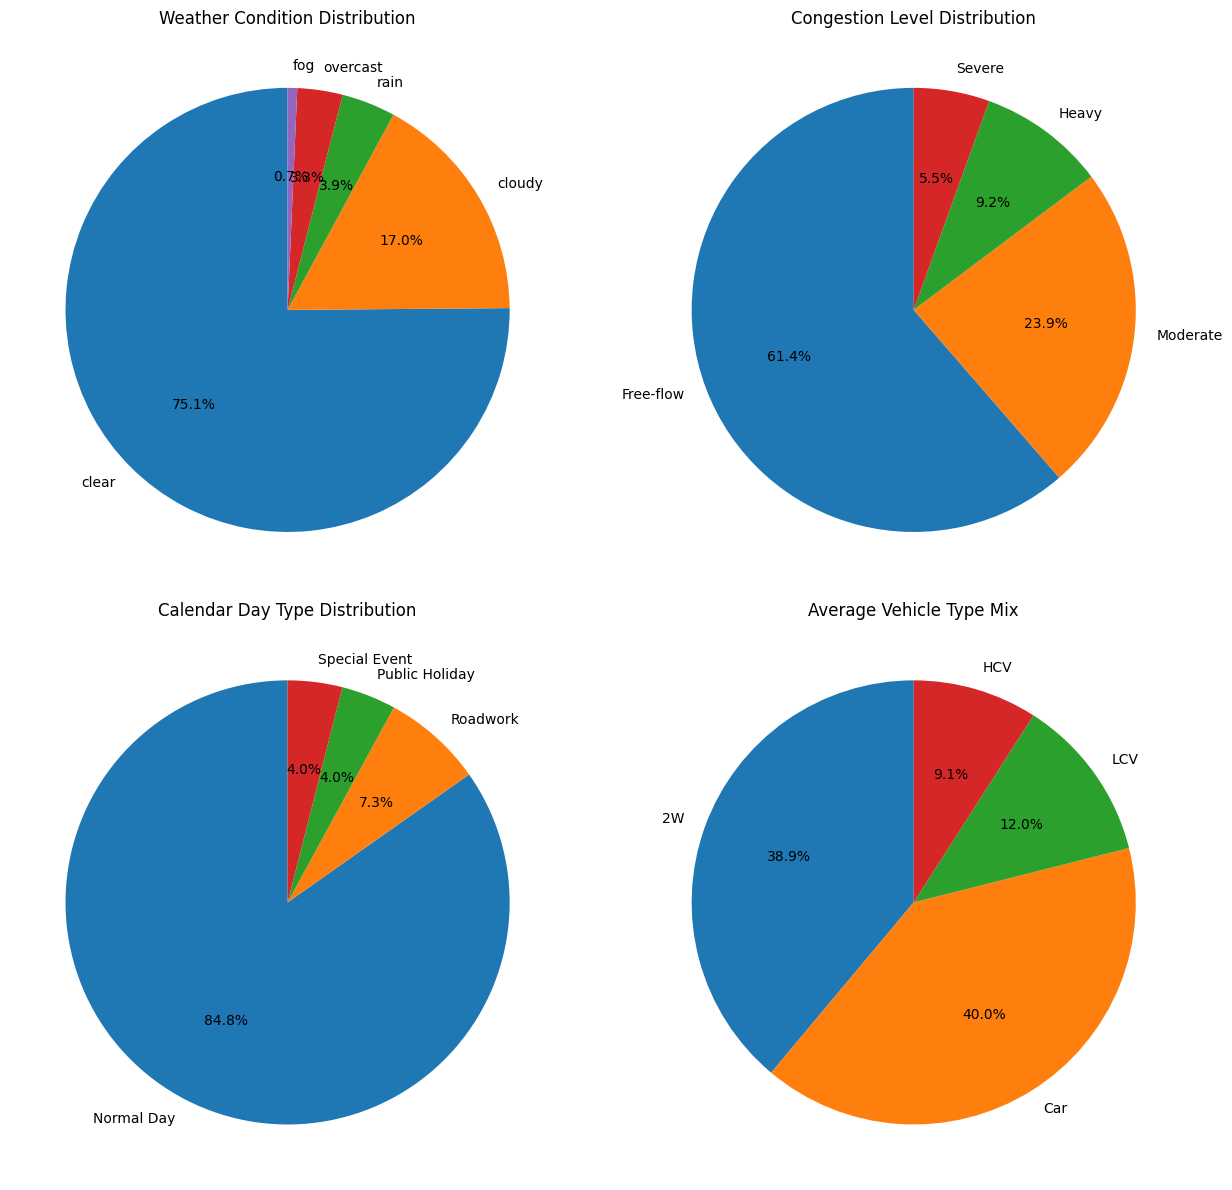

In [7]:
# Calendar day type
def day_type(row):
    if row['public_holiday'] == 1: return 'Public Holiday'
    elif row['event_flag'] == 1: return 'Special Event'
    elif row['roadwork_flag'] == 1: return 'Roadwork'
    else: return 'Normal Day'
calendar['day_type'] = calendar.apply(day_type, axis=1)
day_type_counts = calendar['day_type'].value_counts()

# Vehicle type distribution
def safe_parse(x):
    try: return json.loads(x.replace("'", '"'))
    except: return None
parsed = traffic['vehicle_type_dist'].dropna().apply(safe_parse).dropna()
avg_vehicle_dist = pd.DataFrame(list(parsed)).mean()

# Plot using Pie chart
fig, axes = plt.subplots(2, 2, figsize=(13, 12))
axes[0,0].pie(weather_counts, labels=weather_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Weather Condition Distribution')
axes[0,1].pie(congestion_counts, labels=congestion_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,1].set_title('Congestion Level Distribution')
axes[1,0].pie(day_type_counts, labels=day_type_counts.index, autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Calendar Day Type Distribution')
axes[1,1].pie(avg_vehicle_dist, labels=avg_vehicle_dist.index, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Average Vehicle Type Mix')
plt.tight_layout()

In [8]:
# Clean weather_condition text 
weather['weather_condition'] = weather['weather_condition'].str.strip().str.lower()

weather['weather_condition'] = weather['weather_condition'].replace({
    'rainy': 'rain',
    'foggy': 'fog'
})

# Fill missing weather values
weather['temperature'] = weather['temperature'].fillna(weather['temperature'].mean())
weather['visibility'] = weather['visibility'].fillna(weather['visibility'].mean())

# Remove impossible traffic values 
traffic = traffic[traffic['traffic_volume'] >= 0]

# avg_speed above 120 km/h is unrealistic for city roads, likely a sensor error
traffic = traffic[traffic['avg_speed'] <= 120]

print("\nRows removed due to bad traffic_volume or avg_speed values")

# Fill missing traffic values
traffic['traffic_volume'] = traffic.groupby('road_id')['traffic_volume'].transform(
    lambda x: x.fillna(x.mean())
)
traffic['avg_speed'] = traffic.groupby('road_id')['avg_speed'].transform(
    lambda x: x.fillna(x.mean())
)
traffic['occupancy'] = traffic.groupby('road_id')['occupancy'].transform(
    lambda x: x.fillna(x.mean())
)

# Handle missing congestion_level 
traffic['congestion_level'] = traffic['congestion_level'].fillna('Unknown')

# Remove duplicate rows
weather = weather.drop_duplicates()
calendar = calendar.drop_duplicates()
traffic = traffic.drop_duplicates()

# Check the result
print("\nAfter cleaning:")
print("Weather rows:", len(weather))
print("Calendar rows:", len(calendar))
print("Traffic rows:", len(traffic))

print("\nMissing values left in traffic data:")
print(traffic.isnull().sum())

print("\nMissing values left in weather data:")
print(weather.isnull().sum())

weather.to_csv("weather_cleaned.csv", index=False)
calendar.to_csv("calendar_cleaned.csv", index=False)
traffic.to_csv("traffic_cleaned.csv", index=False)

print("\nCleaned files saved successfully.")


Rows removed due to bad traffic_volume or avg_speed values

After cleaning:
Weather rows: 10872
Calendar rows: 151
Traffic rows: 171887

Missing values left in traffic data:
road_id               0
road_name             0
latitude              0
longitude             0
weather_station_id    0
date                  0
time                  0
traffic_volume        0
vehicle_count         0
vehicle_type_dist     0
avg_speed             0
occupancy             0
congestion_level      0
travel_time           0
accident_count        0
signal_timing         0
road_capacity         0
timestamp             0
dtype: int64

Missing values left in weather data:
station_id                 0
date                       0
time                       0
weather_condition          0
temperature                0
rainfall                   0
visibility                 0
timestamp                  0
weather_condition_clean    0
dtype: int64

Cleaned files saved successfully.


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score

#Load fresh to avoid leftover columns from earlier cells
traffic = pd.read_csv("traffic_cleaned.csv")


# Correlation check
corr = traffic['travel_time'].corr(traffic['avg_speed'])
print(f"Correlation between travel_time and avg_speed: {corr:.4f}")


# Reverse-engineer the hidden formula
sample_road = traffic[traffic['road_id'] == traffic['road_id'].iloc[0]].copy()
sample_road['distance_estimate'] = sample_road['travel_time'] * sample_road['avg_speed']
print(sample_road[['travel_time', 'avg_speed', 'distance_estimate']].head(5))
print(f"Std deviation: {sample_road['distance_estimate'].std():.4f}\n")

# Model comparison - WITH vs WITHOUT leaked features
y = traffic['travel_time']

# drop 'date' AND 'time' AND also 'timestamp' if it exists
cols_to_drop = ['travel_time', 'road_id', 'road_name', 'date', 'time',
                'vehicle_type_dist', 'congestion_level']
cols_to_drop = [c for c in cols_to_drop if c in traffic.columns]
if 'timestamp' in traffic.columns:
    cols_to_drop.append('timestamp')

X_leak = traffic.drop(columns=cols_to_drop)
X_leak = pd.get_dummies(X_leak, columns=['weather_station_id'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_leak, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
r2_leak = r2_score(y_test, model.predict(X_test))

X_clean = X_leak.drop(columns=['avg_speed', 'occupancy'])
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
r2_clean = r2_score(y_test, model.predict(X_test))

print("TRAVEL TIME PREDICTION:")
print(f"  WITH avg_speed/occupancy (leaked):   R2 = {r2_leak:.4f}")
print(f"  WITHOUT avg_speed/occupancy (clean): R2 = {r2_clean:.4f}")

Correlation between travel_time and avg_speed: -0.6727
     travel_time  avg_speed  distance_estimate
0           2.12       31.2             66.144
5           1.96       33.6             65.856
43          1.43       46.2             66.066
58          1.18       56.0             66.080
197         4.89       13.5             66.015
Std deviation: 0.1272

TRAVEL TIME PREDICTION:
  WITH avg_speed/occupancy (leaked):   R2 = 1.0000
  WITHOUT avg_speed/occupancy (clean): R2 = 0.9833


In [11]:
import pandas as pd


traffic = pd.read_csv("traffic_cleaned.csv")

# time features + lag features 
traffic['date'] = pd.to_datetime(traffic['date'])
traffic['timestamp'] = pd.to_datetime(traffic['date'].astype(str) + ' ' + traffic['time'])
traffic = traffic.sort_values(['road_id', 'timestamp'])
traffic['hour'] = traffic['timestamp'].dt.hour
traffic['day_of_week'] = traffic['timestamp'].dt.dayofweek
traffic['is_weekend'] = traffic['day_of_week'].isin([5, 6]).astype(int)
traffic['volume_lag1'] = traffic.groupby('road_id')['traffic_volume'].shift(1)
traffic['volume_lag2'] = traffic.groupby('road_id')['traffic_volume'].shift(2)



# TARGET 1: TRAFFIC VOLUME (regression)
y_volume = traffic['traffic_volume']
X_volume = traffic.drop(columns=['traffic_volume', 'vehicle_count', 'road_id', 'road_name',
    'date', 'time', 'vehicle_type_dist', 'congestion_level', 'timestamp',
    'volume_lag1', 'volume_lag2'])
X_volume = pd.get_dummies(X_volume, columns=['weather_station_id'], drop_first=True)
print("TARGET 1 - Volume | X:", X_volume.shape, "| y:", y_volume.shape)



# TARGET 2: TRAVEL TIME (regression)
# avg_speed & occupancy dropped - direct leakage source (travel_time = distance/avg_speed)
y_traveltime = traffic['travel_time']
X_traveltime = traffic.drop(columns=['travel_time', 'road_id', 'road_name', 'date', 'time',
    'vehicle_type_dist', 'congestion_level', 'timestamp', 'avg_speed', 'occupancy',
    'volume_lag1', 'volume_lag2'])
X_traveltime = pd.get_dummies(X_traveltime, columns=['weather_station_id'], drop_first=True)
print("TARGET 2 - Travel Time | X:", X_traveltime.shape, "| y:", y_traveltime.shape)


# TARGET 3: CONGESTION LEVEL (classification)

traffic_congestion = traffic[traffic['congestion_level'] != 'Unknown'].copy()
traffic_congestion = traffic_congestion.dropna(subset=['volume_lag1', 'volume_lag2'])
congestion_order = {'Free-flow': 0, 'Moderate': 1, 'Heavy': 2, 'Severe': 3}
y_congestion = traffic_congestion['congestion_level'].map(congestion_order)
X_congestion = traffic_congestion[['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
    'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude', 'weather_station_id']]
X_congestion = pd.get_dummies(X_congestion, columns=['weather_station_id'], drop_first=True)
print("TARGET 3 - Congestion | X:", X_congestion.shape, "| y:", y_congestion.shape)



# TARGET 4: ACCIDENT RISK (binary classification, imbalanced)
traffic_accident = traffic.dropna(subset=['volume_lag1', 'volume_lag2']).copy()
y_accident = (traffic_accident['accident_count'] > 0).astype(int)
X_accident = traffic_accident[['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
    'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude', 'weather_station_id']]
X_accident = pd.get_dummies(X_accident, columns=['weather_station_id'], drop_first=True)
print("TARGET 4 - Accident Risk | X:", X_accident.shape, "| y:", y_accident.shape)

TARGET 1 - Volume | X: (171887, 13) | y: (171887,)
TARGET 2 - Travel Time | X: (171887, 12) | y: (171887,)
TARGET 3 - Congestion | X: (145934, 11) | y: (145934,)
TARGET 4 - Accident Risk | X: (171837, 11) | y: (171837,)


In [12]:
import pandas as pd

traffic = pd.read_csv("traffic_cleaned.csv")


traffic['date'] = pd.to_datetime(traffic['date'])
traffic['timestamp'] = pd.to_datetime(traffic['date'].astype(str) + ' ' + traffic['time'])
traffic = traffic.sort_values(['road_id', 'timestamp'])
traffic['hour'] = traffic['timestamp'].dt.hour
traffic['day_of_week'] = traffic['timestamp'].dt.dayofweek
traffic['is_weekend'] = traffic['day_of_week'].isin([5, 6]).astype(int)
traffic['volume_lag1'] = traffic.groupby('road_id')['traffic_volume'].shift(1)
traffic['volume_lag2'] = traffic.groupby('road_id')['traffic_volume'].shift(2)

# Ordinal mapping used wherever congestion_level appears
congestion_order = {'Free-flow': 0, 'Moderate': 1, 'Heavy': 2, 'Severe': 3}


# TARGET 1: Volume 

y_volume = traffic['traffic_volume']
X_volume = traffic.drop(columns=['traffic_volume', 'vehicle_count', 'road_id', 'road_name',
    'date', 'time', 'vehicle_type_dist', 'congestion_level', 'timestamp', 'volume_lag1', 'volume_lag2'])
X_volume = pd.get_dummies(X_volume, columns=['weather_station_id'], drop_first=True)
print("TARGET 1 - Volume | categorical -> one-hot (weather_station_id)")
print(X_volume.filter(like='weather_station_id').columns.tolist())


# TARGET 2: Travel Time

y_traveltime = traffic['travel_time']
X_traveltime = traffic.drop(columns=['travel_time', 'road_id', 'road_name', 'date', 'time',
    'vehicle_type_dist', 'congestion_level', 'timestamp', 'avg_speed', 'occupancy',
    'volume_lag1', 'volume_lag2'])
X_traveltime = pd.get_dummies(X_traveltime, columns=['weather_station_id'], drop_first=True)
print("\nTARGET 2 - Travel Time | categorical -> one-hot (weather_station_id)")


# ===== TARGET 3: Congestion Level =====

traffic_congestion = traffic[traffic['congestion_level'] != 'Unknown'].copy()
traffic_congestion = traffic_congestion.dropna(subset=['volume_lag1', 'volume_lag2'])
y_congestion = traffic_congestion['congestion_level'].map(congestion_order)  # ordinal encoding
X_congestion = traffic_congestion[['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
    'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude', 'weather_station_id']]
X_congestion = pd.get_dummies(X_congestion, columns=['weather_station_id'], drop_first=True)
print("\nTARGET 3 - Congestion | target -> ordinal, feature -> one-hot")
print("y unique values:", sorted(y_congestion.unique()))


# ===== TARGET 4: Accident Risk =====

traffic_accident = traffic.dropna(subset=['volume_lag1', 'volume_lag2']).copy()
y_accident = (traffic_accident['accident_count'] > 0).astype(int)  # binarize
X_accident = traffic_accident[['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
    'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude', 'weather_station_id']]
X_accident = pd.get_dummies(X_accident, columns=['weather_station_id'], drop_first=True)
print("\nTARGET 4 - Accident Risk | target -> binarized, feature -> one-hot")
print("y value counts:\n", y_accident.value_counts())

TARGET 1 - Volume | categorical -> one-hot (weather_station_id)
['weather_station_id_WS-NORTH', 'weather_station_id_WS-SOUTH']

TARGET 2 - Travel Time | categorical -> one-hot (weather_station_id)

TARGET 3 - Congestion | target -> ordinal, feature -> one-hot
y unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

TARGET 4 - Accident Risk | target -> binarized, feature -> one-hot
y value counts:
 accident_count
0    170235
1      1602
Name: count, dtype: int64


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split


traffic = pd.read_csv("traffic_cleaned.csv")
traffic['date'] = pd.to_datetime(traffic['date'])
traffic['timestamp'] = pd.to_datetime(traffic['date'].astype(str) + ' ' + traffic['time'])
traffic = traffic.sort_values(['road_id', 'timestamp'])
traffic['hour'] = traffic['timestamp'].dt.hour
traffic['day_of_week'] = traffic['timestamp'].dt.dayofweek
traffic['is_weekend'] = traffic['day_of_week'].isin([5, 6]).astype(int)
traffic['volume_lag1'] = traffic.groupby('road_id')['traffic_volume'].shift(1)
traffic['volume_lag2'] = traffic.groupby('road_id')['traffic_volume'].shift(2)

congestion_order = {'Free-flow': 0, 'Moderate': 1, 'Heavy': 2, 'Severe': 3}


#  TARGET 1: Volume 
y_volume = traffic['traffic_volume']
X_volume = traffic.drop(columns=['traffic_volume', 'vehicle_count', 'road_id', 'road_name',
    'date', 'time', 'vehicle_type_dist', 'congestion_level', 'timestamp', 'volume_lag1', 'volume_lag2'])
X_volume = pd.get_dummies(X_volume, columns=['weather_station_id'], drop_first=True)

Xv_train, Xv_test, yv_train, yv_test = train_test_split(
    X_volume, y_volume, test_size=0.2, random_state=42
)
print("VOLUME       -> Train:", Xv_train.shape, "Test:", Xv_test.shape)


# TARGET 2: Travel Time 
y_traveltime = traffic['travel_time']
X_traveltime = traffic.drop(columns=['travel_time', 'road_id', 'road_name', 'date', 'time',
    'vehicle_type_dist', 'congestion_level', 'timestamp', 'avg_speed', 'occupancy',
    'volume_lag1', 'volume_lag2'])
X_traveltime = pd.get_dummies(X_traveltime, columns=['weather_station_id'], drop_first=True)

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_traveltime, y_traveltime, test_size=0.2, random_state=42
)
print("TRAVEL TIME  -> Train:", Xt_train.shape, "Test:", Xt_test.shape)


# TARGET 3: Congestion Level 

traffic_congestion = traffic[traffic['congestion_level'] != 'Unknown'].copy()
traffic_congestion = traffic_congestion.dropna(subset=['volume_lag1', 'volume_lag2'])
y_congestion = traffic_congestion['congestion_level'].map(congestion_order)
X_congestion = traffic_congestion[['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
    'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude', 'weather_station_id']]
X_congestion = pd.get_dummies(X_congestion, columns=['weather_station_id'], drop_first=True)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_congestion, y_congestion, test_size=0.2, random_state=42, stratify=y_congestion
)
print("CONGESTION   -> Train:", Xc_train.shape, "Test:", Xc_test.shape)


# TARGET 4: Accident Risk 

traffic_accident = traffic.dropna(subset=['volume_lag1', 'volume_lag2']).copy()
y_accident = (traffic_accident['accident_count'] > 0).astype(int)
X_accident = traffic_accident[['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
    'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude', 'weather_station_id']]
X_accident = pd.get_dummies(X_accident, columns=['weather_station_id'], drop_first=True)

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_accident, y_accident, test_size=0.2, random_state=42, stratify=y_accident
)
print("ACCIDENT RISK-> Train:", Xa_train.shape, "Test:", Xa_test.shape)

VOLUME       -> Train: (137509, 13) Test: (34378, 13)
TRAVEL TIME  -> Train: (137509, 12) Test: (34378, 12)
CONGESTION   -> Train: (116747, 11) Test: (29187, 11)
ACCIDENT RISK-> Train: (137469, 11) Test: (34368, 11)


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


traffic = pd.read_csv("traffic_cleaned.csv")
traffic['date'] = pd.to_datetime(traffic['date'])
traffic['timestamp'] = pd.to_datetime(traffic['date'].astype(str) + ' ' + traffic['time'])
traffic = traffic.sort_values(['road_id', 'timestamp'])
traffic['hour'] = traffic['timestamp'].dt.hour
traffic['day_of_week'] = traffic['timestamp'].dt.dayofweek
traffic['is_weekend'] = traffic['day_of_week'].isin([5, 6]).astype(int)
traffic['volume_lag1'] = traffic.groupby('road_id')['traffic_volume'].shift(1)
traffic['volume_lag2'] = traffic.groupby('road_id')['traffic_volume'].shift(2)

congestion_order = {'Free-flow': 0, 'Moderate': 1, 'Heavy': 2, 'Severe': 3}


# TARGET 1: Volume 
y_volume = traffic['traffic_volume']
X_volume = traffic.drop(columns=['traffic_volume', 'vehicle_count', 'road_id', 'road_name',
    'date', 'time', 'vehicle_type_dist', 'congestion_level', 'timestamp', 'volume_lag1', 'volume_lag2'])
X_volume = pd.get_dummies(X_volume, columns=['weather_station_id'], drop_first=True)
Xv_train, Xv_test, yv_train, yv_test = train_test_split(X_volume, y_volume, test_size=0.2, random_state=42)

scaler_v = StandardScaler()
Xv_train_scaled = pd.DataFrame(scaler_v.fit_transform(Xv_train), columns=Xv_train.columns, index=Xv_train.index)
Xv_test_scaled = pd.DataFrame(scaler_v.transform(Xv_test), columns=Xv_test.columns, index=Xv_test.index)
print("VOLUME scaled -> Train:", Xv_train_scaled.shape, "Test:", Xv_test_scaled.shape)


# TARGET 2: Travel Time 
y_traveltime = traffic['travel_time']
X_traveltime = traffic.drop(columns=['travel_time', 'road_id', 'road_name', 'date', 'time',
    'vehicle_type_dist', 'congestion_level', 'timestamp', 'avg_speed', 'occupancy',
    'volume_lag1', 'volume_lag2'])
X_traveltime = pd.get_dummies(X_traveltime, columns=['weather_station_id'], drop_first=True)
Xt_train, Xt_test, yt_train, yt_test = train_test_split(X_traveltime, y_traveltime, test_size=0.2, random_state=42)

scaler_t = StandardScaler()
Xt_train_scaled = pd.DataFrame(scaler_t.fit_transform(Xt_train), columns=Xt_train.columns, index=Xt_train.index)
Xt_test_scaled = pd.DataFrame(scaler_t.transform(Xt_test), columns=Xt_test.columns, index=Xt_test.index)
print("TRAVEL TIME scaled -> Train:", Xt_train_scaled.shape, "Test:", Xt_test_scaled.shape)


# TARGET 3: Congestion Level 
traffic_congestion = traffic[traffic['congestion_level'] != 'Unknown'].copy()
traffic_congestion = traffic_congestion.dropna(subset=['volume_lag1', 'volume_lag2'])
y_congestion = traffic_congestion['congestion_level'].map(congestion_order)
X_congestion = traffic_congestion[['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
    'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude', 'weather_station_id']]
X_congestion = pd.get_dummies(X_congestion, columns=['weather_station_id'], drop_first=True)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_congestion, y_congestion, test_size=0.2,
    random_state=42, stratify=y_congestion)

scaler_c = StandardScaler()
Xc_train_scaled = pd.DataFrame(scaler_c.fit_transform(Xc_train), columns=Xc_train.columns, index=Xc_train.index)
Xc_test_scaled = pd.DataFrame(scaler_c.transform(Xc_test), columns=Xc_test.columns, index=Xc_test.index)
print("CONGESTION scaled -> Train:", Xc_train_scaled.shape, "Test:", Xc_test_scaled.shape)


# TARGET 4: Accident Risk 
traffic_accident = traffic.dropna(subset=['volume_lag1', 'volume_lag2']).copy()
y_accident = (traffic_accident['accident_count'] > 0).astype(int)
X_accident = traffic_accident[['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
    'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude', 'weather_station_id']]
X_accident = pd.get_dummies(X_accident, columns=['weather_station_id'], drop_first=True)
Xa_train, Xa_test, ya_train, ya_test = train_test_split(X_accident, y_accident, test_size=0.2,
    random_state=42, stratify=y_accident)

scaler_a = StandardScaler()
Xa_train_scaled = pd.DataFrame(scaler_a.fit_transform(Xa_train), columns=Xa_train.columns, index=Xa_train.index)
Xa_test_scaled = pd.DataFrame(scaler_a.transform(Xa_test), columns=Xa_test.columns, index=Xa_test.index)
print("ACCIDENT RISK scaled -> Train:", Xa_train_scaled.shape, "Test:", Xa_test_scaled.shape)

VOLUME scaled -> Train: (137509, 13) Test: (34378, 13)
TRAVEL TIME scaled -> Train: (137509, 12) Test: (34378, 12)
CONGESTION scaled -> Train: (116747, 11) Test: (29187, 11)
ACCIDENT RISK scaled -> Train: (137469, 11) Test: (34368, 11)


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, classification_report, roc_auc_score,
                              confusion_matrix)


traffic = pd.read_csv("traffic_cleaned.csv")
traffic['date'] = pd.to_datetime(traffic['date'])
traffic['timestamp'] = pd.to_datetime(traffic['date'].astype(str) + ' ' + traffic['time'])
traffic = traffic.sort_values(['road_id', 'timestamp'])
traffic['hour'] = traffic['timestamp'].dt.hour
traffic['day_of_week'] = traffic['timestamp'].dt.dayofweek
traffic['is_weekend'] = traffic['day_of_week'].isin([5, 6]).astype(int)
traffic['volume_lag1'] = traffic.groupby('road_id')['traffic_volume'].shift(1)
traffic['volume_lag2'] = traffic.groupby('road_id')['traffic_volume'].shift(2)

congestion_order = {'Free-flow': 0, 'Moderate': 1, 'Heavy': 2, 'Severe': 3}



# TARGET 1: TRAFFIC VOLUME - Linear Regression

print("="*60, "\nTARGET 1: TRAFFIC VOLUME - Linear Regression\n", "="*60)

y = traffic['traffic_volume']
X = traffic.drop(columns=['traffic_volume', 'vehicle_count', 'road_id', 'road_name',
    'date', 'time', 'vehicle_type_dist', 'congestion_level', 'timestamp',
    'volume_lag1', 'volume_lag2'])
X = pd.get_dummies(X, columns=['weather_station_id'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model_volume = LinearRegression()
model_volume.fit(X_train_s, y_train)
y_pred = model_volume.predict(X_test_s)

print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 3))
print("R2:", round(r2_score(y_test, y_pred), 3))



# TARGET 2: TRAVEL TIME - Linear Regression

print("\n" + "="*60, "\nTARGET 2: TRAVEL TIME - Linear Regression\n", "="*60)

y = traffic['travel_time']
X = traffic.drop(columns=['travel_time', 'road_id', 'road_name', 'date', 'time',
    'vehicle_type_dist', 'congestion_level', 'timestamp', 'avg_speed', 'occupancy',
    'volume_lag1', 'volume_lag2'])
X = pd.get_dummies(X, columns=['weather_station_id'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model_traveltime = LinearRegression()
model_traveltime.fit(X_train_s, y_train)
y_pred = model_traveltime.predict(X_test_s)

print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 3))
print("R2:", round(r2_score(y_test, y_pred), 3))



# TARGET 3: CONGESTION LEVEL - Logistic Regression (multi-class)

print("\n" + "="*60, "\nTARGET 3: CONGESTION LEVEL - Logistic Regression\n", "="*60)

traffic_c = traffic[traffic['congestion_level'] != 'Unknown'].copy()
traffic_c = traffic_c.dropna(subset=['volume_lag1', 'volume_lag2'])
y = traffic_c['congestion_level'].map(congestion_order)
X = traffic_c[['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
    'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude', 'weather_station_id']]
X = pd.get_dummies(X, columns=['weather_station_id'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model_congestion = LogisticRegression(max_iter=1000, class_weight='balanced')
model_congestion.fit(X_train_s, y_train)
y_pred = model_congestion.predict(X_test_s)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred, target_names=['Free-flow','Moderate','Heavy','Severe']))



# TARGET 4: ACCIDENT RISK - Logistic Regression (binary, imbalanced)

print("\n" + "="*60, "\nTARGET 4: ACCIDENT RISK - Logistic Regression\n", "="*60)

traffic_a = traffic.dropna(subset=['volume_lag1', 'volume_lag2']).copy()
y = (traffic_a['accident_count'] > 0).astype(int)
X = traffic_a[['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
    'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude', 'weather_station_id']]
X = pd.get_dummies(X, columns=['weather_station_id'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model_accident = LogisticRegression(max_iter=1000, class_weight='balanced')
model_accident.fit(X_train_s, y_train)
y_pred = model_accident.predict(X_test_s)
y_proba = model_accident.predict_proba(X_test_s)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print(classification_report(y_test, y_pred, target_names=['No Accident', 'Accident']))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

TARGET 1: TRAFFIC VOLUME - Linear Regression
RMSE: 76.478
MAE: 52.906
R2: 0.927

TARGET 2: TRAVEL TIME - Linear Regression
RMSE: 1.887
MAE: 1.208
R2: 0.444

TARGET 3: CONGESTION LEVEL - Logistic Regression
Accuracy: 0.8034
              precision    recall  f1-score   support

   Free-flow       0.96      0.89      0.93     17916
    Moderate       0.67      0.72      0.69      6963
       Heavy       0.45      0.49      0.47      2701
      Severe       0.51      0.69      0.59      1607

    accuracy                           0.80     29187
   macro avg       0.65      0.70      0.67     29187
weighted avg       0.82      0.80      0.81     29187


TARGET 4: ACCIDENT RISK - Logistic Regression
Accuracy: 0.6357
ROC-AUC: 0.5759
              precision    recall  f1-score   support

 No Accident       0.99      0.64      0.78     34048
    Accident       0.01      0.46      0.02       320

    accuracy                           0.64     34368
   macro avg       0.50      0.55      0.40 

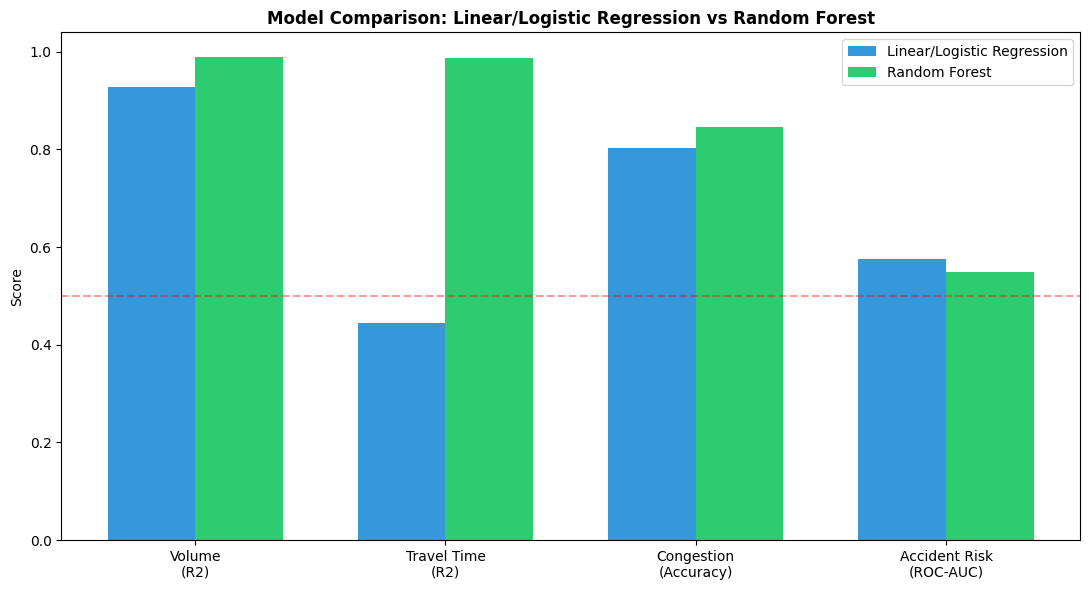

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score, roc_auc_score

traffic = pd.read_csv("traffic_cleaned.csv")
traffic['date'] = pd.to_datetime(traffic['date'])
traffic['timestamp'] = pd.to_datetime(traffic['date'].astype(str) + ' ' + traffic['time'])
traffic = traffic.sort_values(['road_id', 'timestamp'])
traffic['hour'] = traffic['timestamp'].dt.hour
traffic['day_of_week'] = traffic['timestamp'].dt.dayofweek
traffic['is_weekend'] = traffic['day_of_week'].isin([5, 6]).astype(int)
traffic['volume_lag1'] = traffic.groupby('road_id')['traffic_volume'].shift(1)
traffic['volume_lag2'] = traffic.groupby('road_id')['traffic_volume'].shift(2)
congestion_order = {'Free-flow': 0, 'Moderate': 1, 'Heavy': 2, 'Severe': 3}

results = []

# ===== VOLUME =====
y = traffic['traffic_volume']
X = traffic.drop(columns=['traffic_volume', 'vehicle_count', 'road_id', 'road_name',
    'date', 'time', 'vehicle_type_dist', 'congestion_level', 'timestamp', 'volume_lag1', 'volume_lag2'])
X = pd.get_dummies(X, columns=['weather_station_id'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
lr = LinearRegression().fit(scaler.fit_transform(X_train), y_train)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)
results.append(('Volume', 'Linear Reg', r2_score(y_test, lr.predict(scaler.transform(X_test)))))
results.append(('Volume', 'Random Forest', r2_score(y_test, rf.predict(X_test))))

# ===== TRAVEL TIME =====
y = traffic['travel_time']
X = traffic.drop(columns=['travel_time', 'road_id', 'road_name', 'date', 'time',
    'vehicle_type_dist', 'congestion_level', 'timestamp', 'avg_speed', 'occupancy', 'volume_lag1', 'volume_lag2'])
X = pd.get_dummies(X, columns=['weather_station_id'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
lr = LinearRegression().fit(scaler.fit_transform(X_train), y_train)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)
results.append(('Travel Time', 'Linear Reg', r2_score(y_test, lr.predict(scaler.transform(X_test)))))
results.append(('Travel Time', 'Random Forest', r2_score(y_test, rf.predict(X_test))))

# ===== CONGESTION =====
traffic_c = traffic[traffic['congestion_level'] != 'Unknown'].copy().dropna(subset=['volume_lag1','volume_lag2'])
y = traffic_c['congestion_level'].map(congestion_order)
X = traffic_c[['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
    'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude', 'weather_station_id']]
X = pd.get_dummies(X, columns=['weather_station_id'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
lr = LogisticRegression(max_iter=1000, class_weight='balanced').fit(scaler.fit_transform(X_train), y_train)
rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1, class_weight='balanced').fit(X_train, y_train)
results.append(('Congestion', 'Logistic Reg', accuracy_score(y_test, lr.predict(scaler.transform(X_test)))))
results.append(('Congestion', 'Random Forest', accuracy_score(y_test, rf.predict(X_test))))

# ===== ACCIDENT RISK - use ROC-AUC, NOT accuracy (data is 99% imbalanced) =====
traffic_a = traffic.dropna(subset=['volume_lag1', 'volume_lag2']).copy()
y = (traffic_a['accident_count'] > 0).astype(int)
X = traffic_a[['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
    'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude', 'weather_station_id']]
X = pd.get_dummies(X, columns=['weather_station_id'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
lr = LogisticRegression(max_iter=1000, class_weight='balanced').fit(scaler.fit_transform(X_train), y_train)
rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1, class_weight='balanced').fit(X_train, y_train)
lr_auc = roc_auc_score(y_test, lr.predict_proba(scaler.transform(X_test))[:,1])
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
results.append(('Accident Risk', 'Logistic Reg', lr_auc))
results.append(('Accident Risk', 'Random Forest', rf_auc))

# ===== Plot comparison =====
df = pd.DataFrame(results, columns=['Target', 'Model', 'Score'])
fig, ax = plt.subplots(figsize=(11, 6))
targets = df['Target'].unique()
x = range(len(targets))
width = 0.35
linear_scores = [df[(df['Target']==t) & (df['Model'].isin(['Linear Reg','Logistic Reg']))]['Score'].values[0] for t in targets]
rf_scores = [df[(df['Target']==t) & (df['Model']=='Random Forest')]['Score'].values[0] for t in targets]

ax.bar([i - width/2 for i in x], linear_scores, width, label='Linear/Logistic Regression', color='#3498DB')
ax.bar([i + width/2 for i in x], rf_scores, width, label='Random Forest', color='#2ECC71')
ax.set_xticks(list(x))
ax.set_xticklabels(['Volume\n(R2)', 'Travel Time\n(R2)', 'Congestion\n(Accuracy)', 'Accident Risk\n(ROC-AUC)'])
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Linear/Logistic Regression vs Random Forest', fontweight='bold')
ax.legend()
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, roc_auc_score

# ===== Load & shared setup =====
traffic = pd.read_csv("traffic_cleaned.csv")
traffic['date'] = pd.to_datetime(traffic['date'])
traffic['timestamp'] = pd.to_datetime(traffic['date'].astype(str) + ' ' + traffic['time'])
traffic = traffic.sort_values(['road_id', 'timestamp'])
traffic['hour'] = traffic['timestamp'].dt.hour
traffic['day_of_week'] = traffic['timestamp'].dt.dayofweek
traffic['is_weekend'] = traffic['day_of_week'].isin([5, 6]).astype(int)
traffic['volume_lag1'] = traffic.groupby('road_id')['traffic_volume'].shift(1)
traffic['volume_lag2'] = traffic.groupby('road_id')['traffic_volume'].shift(2)
congestion_order = {'Free-flow': 0, 'Moderate': 1, 'Heavy': 2, 'Severe': 3}


# ===== MODEL 1: TRAFFIC VOLUME (Random Forest Regressor) =====
y1 = traffic['traffic_volume']
X1 = traffic.drop(columns=['traffic_volume', 'vehicle_count', 'road_id', 'road_name',
    'date', 'time', 'vehicle_type_dist', 'congestion_level', 'timestamp', 'volume_lag1', 'volume_lag2'])
X1 = pd.get_dummies(X1, columns=['weather_station_id'], drop_first=True)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

model_volume = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
model_volume.fit(X1_train, y1_train)
pred1 = model_volume.predict(X1_test)
print("MODEL 1 - Traffic Volume | R2:", round(r2_score(y1_test, pred1), 4))
joblib.dump(model_volume, 'model_volume.pkl', compress=3)
joblib.dump(list(X1.columns), 'model_volume_features.pkl')


# ===== MODEL 2: TRAVEL TIME (Random Forest Regressor) =====
y2 = traffic['travel_time']
X2 = traffic.drop(columns=['travel_time', 'road_id', 'road_name', 'date', 'time',
    'vehicle_type_dist', 'congestion_level', 'timestamp', 'avg_speed', 'occupancy', 'volume_lag1', 'volume_lag2'])
X2 = pd.get_dummies(X2, columns=['weather_station_id'], drop_first=True)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

model_traveltime = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
model_traveltime.fit(X2_train, y2_train)
pred2 = model_traveltime.predict(X2_test)
print("MODEL 2 - Travel Time | R2:", round(r2_score(y2_test, pred2), 4))
joblib.dump(model_traveltime, 'model_traveltime.pkl', compress=3)
joblib.dump(list(X2.columns), 'model_traveltime_features.pkl')


# ===== MODEL 3: CONGESTION LEVEL (Random Forest Classifier) =====
traffic_c = traffic[traffic['congestion_level'] != 'Unknown'].copy().dropna(subset=['volume_lag1','volume_lag2'])
y3 = traffic_c['congestion_level'].map(congestion_order)
X3 = traffic_c[['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
    'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude', 'weather_station_id']]
X3 = pd.get_dummies(X3, columns=['weather_station_id'], drop_first=True)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

model_congestion = RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1, class_weight='balanced')
model_congestion.fit(X3_train, y3_train)
pred3 = model_congestion.predict(X3_test)
print("MODEL 3 - Congestion Level | Accuracy:", round(accuracy_score(y3_test, pred3), 4))
joblib.dump(model_congestion, 'model_congestion.pkl', compress=3)
joblib.dump(list(X3.columns), 'model_congestion_features.pkl')


# ===== MODEL 4: ACCIDENT RISK (Logistic Regression - better ROC-AUC than RF) =====
traffic_a = traffic.dropna(subset=['volume_lag1', 'volume_lag2']).copy()
y4 = (traffic_a['accident_count'] > 0).astype(int)
X4 = traffic_a[['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
    'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude', 'weather_station_id']]
X4 = pd.get_dummies(X4, columns=['weather_station_id'], drop_first=True)
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42, stratify=y4)

scaler_accident = StandardScaler()
X4_train_s = scaler_accident.fit_transform(X4_train)
X4_test_s = scaler_accident.transform(X4_test)

model_accident = LogisticRegression(max_iter=1000, class_weight='balanced')
model_accident.fit(X4_train_s, y4_train)
pred4 = model_accident.predict(X4_test_s)
proba4 = model_accident.predict_proba(X4_test_s)[:, 1]
print("MODEL 4 - Accident Risk | ROC-AUC:", round(roc_auc_score(y4_test, proba4), 4))
joblib.dump(model_accident, 'model_accident.pkl', compress=3)
joblib.dump(scaler_accident, 'model_accident_scaler.pkl', compress=3)
joblib.dump(list(X4.columns), 'model_accident_features.pkl')

print("\nAll 4 models trained and saved successfully.")

MODEL 1 - Traffic Volume | R2: 0.9905
MODEL 2 - Travel Time | R2: 0.987
MODEL 3 - Congestion Level | Accuracy: 0.8393
MODEL 4 - Accident Risk | ROC-AUC: 0.5759

All 4 models trained and saved successfully.


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score, roc_auc_score

traffic = pd.read_csv("traffic_merged.csv", low_memory=False)
traffic['date'] = pd.to_datetime(traffic['date'])
traffic['timestamp'] = pd.to_datetime(traffic['timestamp'])
traffic = traffic.sort_values(['road_id', 'timestamp'])
traffic['hour'] = traffic['timestamp'].dt.hour
traffic['day_of_week'] = traffic['timestamp'].dt.dayofweek
traffic['is_weekend'] = traffic['day_of_week'].isin([5, 6]).astype(int)
traffic['volume_lag1'] = traffic.groupby('road_id')['traffic_volume'].shift(1)
traffic['volume_lag2'] = traffic.groupby('road_id')['traffic_volume'].shift(2)
congestion_order = {'Free-flow': 0, 'Moderate': 1, 'Heavy': 2, 'Severe': 3}


# ===== MODEL 1: VOLUME =====
y1 = traffic['traffic_volume']
keep_cols_1 = ['latitude', 'longitude', 'avg_speed', 'occupancy', 'travel_time',
               'accident_count', 'signal_timing', 'road_capacity', 'hour', 'day_of_week', 'is_weekend',
               'weather_station_id', 'weather_condition', 'temperature', 'rainfall', 'visibility',
               'public_holiday', 'event_flag', 'roadwork_flag']
X1 = traffic[keep_cols_1].copy()
X1 = pd.get_dummies(X1, columns=['weather_station_id', 'weather_condition'], drop_first=True)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
model1 = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
model1.fit(X1_train, y1_train)
print("VOLUME R2:", round(r2_score(y1_test, model1.predict(X1_test)), 4))


# ===== MODEL 2: TRAVEL TIME =====
y2 = traffic['travel_time']
keep_cols_2 = ['latitude', 'longitude', 'traffic_volume', 'vehicle_count',
               'accident_count', 'signal_timing', 'road_capacity', 'hour', 'day_of_week', 'is_weekend',
               'weather_station_id', 'weather_condition', 'temperature', 'rainfall', 'visibility',
               'public_holiday', 'event_flag', 'roadwork_flag']
X2 = traffic[keep_cols_2].copy()
X2 = pd.get_dummies(X2, columns=['weather_station_id', 'weather_condition'], drop_first=True)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
model2 = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
model2.fit(X2_train, y2_train)
print("TRAVEL TIME R2:", round(r2_score(y2_test, model2.predict(X2_test)), 4))


# ===== MODEL 3: CONGESTION =====
traffic_c = traffic[traffic['congestion_level'] != 'Unknown'].copy().dropna(subset=['volume_lag1','volume_lag2'])
y3 = traffic_c['congestion_level'].map(congestion_order)
keep_cols_3 = ['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
               'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude',
               'weather_station_id', 'weather_condition', 'temperature', 'rainfall', 'visibility',
               'public_holiday', 'event_flag', 'roadwork_flag']
X3 = traffic_c[keep_cols_3].copy()
X3 = pd.get_dummies(X3, columns=['weather_station_id', 'weather_condition'], drop_first=True)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)
model3 = RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1, class_weight='balanced')
model3.fit(X3_train, y3_train)
print("CONGESTION Accuracy:", round(accuracy_score(y3_test, model3.predict(X3_test)), 4))


# ===== MODEL 4: ACCIDENT RISK =====
traffic_a = traffic.dropna(subset=['volume_lag1', 'volume_lag2']).copy()
y4 = (traffic_a['accident_count'] > 0).astype(int)
keep_cols_4 = ['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
               'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude',
               'weather_station_id', 'weather_condition', 'temperature', 'rainfall', 'visibility',
               'public_holiday', 'event_flag', 'roadwork_flag']
X4 = traffic_a[keep_cols_4].copy()
X4 = pd.get_dummies(X4, columns=['weather_station_id', 'weather_condition'], drop_first=True)
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42, stratify=y4)
scaler = StandardScaler()
X4_train_s = scaler.fit_transform(X4_train)
X4_test_s = scaler.transform(X4_test)
model4 = LogisticRegression(max_iter=1000, class_weight='balanced')
model4.fit(X4_train_s, y4_train)
proba4 = model4.predict_proba(X4_test_s)[:, 1]
print("ACCIDENT RISK ROC-AUC:", round(roc_auc_score(y4_test, proba4), 4))

VOLUME R2: 0.9922
TRAVEL TIME R2: 0.991
CONGESTION Accuracy: 0.8451
ACCIDENT RISK ROC-AUC: 0.637


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE

# ===== Load merged data and build richer features =====
traffic = pd.read_csv("traffic_merged.csv", low_memory=False)
traffic['date'] = pd.to_datetime(traffic['date'])
traffic['timestamp'] = pd.to_datetime(traffic['timestamp'])
traffic = traffic.sort_values(['road_id', 'timestamp'])

traffic['hour'] = traffic['timestamp'].dt.hour
traffic['day_of_week'] = traffic['timestamp'].dt.dayofweek
traffic['is_weekend'] = traffic['day_of_week'].isin([5, 6]).astype(int)
traffic['is_rush_hour'] = traffic['hour'].isin([7,8,9,17,18,19]).astype(int)

traffic['volume_lag1'] = traffic.groupby('road_id')['traffic_volume'].shift(1)
traffic['volume_lag2'] = traffic.groupby('road_id')['traffic_volume'].shift(2)
traffic['volume_lag3'] = traffic.groupby('road_id')['traffic_volume'].shift(3)
traffic['volume_change'] = traffic['volume_lag1'] - traffic['volume_lag2']
traffic['volume_change_pct'] = (traffic['volume_lag1'] - traffic['volume_lag2']) / (traffic['volume_lag2'] + 1)
traffic['volume_rolling_mean3'] = traffic.groupby('road_id')['traffic_volume'].transform(
    lambda x: x.shift(1).rolling(3).mean())

traffic['bad_weather'] = traffic['weather_condition'].isin(['rain', 'fog']).astype(int)
traffic['low_visibility'] = (traffic['visibility'] < traffic['visibility'].quantile(0.25)).astype(int)


# ===== Build X, y =====
traffic_a = traffic.dropna(subset=['volume_lag1', 'volume_lag2', 'volume_lag3',
                                     'volume_change', 'volume_rolling_mean3']).copy()
y = (traffic_a['accident_count'] > 0).astype(int)

keep_cols = ['volume_lag1', 'volume_lag2', 'volume_lag3', 'volume_change', 'volume_change_pct',
             'volume_rolling_mean3', 'signal_timing', 'road_capacity',
             'hour', 'day_of_week', 'is_weekend', 'is_rush_hour',
             'latitude', 'longitude', 'weather_station_id', 'weather_condition',
             'temperature', 'rainfall', 'visibility', 'bad_weather', 'low_visibility',
             'public_holiday', 'event_flag', 'roadwork_flag']
X = traffic_a[keep_cols].copy()
X = pd.get_dummies(X, columns=['weather_station_id', 'weather_condition'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ===== Scale, then apply SMOTE to TRAINING data only =====
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_s, y_train)

# ===== Train Logistic Regression on the balanced data =====
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_smote, y_train_smote)
proba_lr = model_lr.predict_proba(X_test_s)[:, 1]
print("ROC-AUC:", round(roc_auc_score(y_test, proba_lr), 4))
print(classification_report(y_test, model_lr.predict(X_test_s), target_names=['No Accident','Accident']))

ROC-AUC: 0.6349
              precision    recall  f1-score   support

 No Accident       0.99      0.76      0.86     34043
    Accident       0.02      0.48      0.04       320

    accuracy                           0.75     34363
   macro avg       0.51      0.62      0.45     34363
weighted avg       0.98      0.75      0.85     34363



In [1]:
"""
Hyperparameter Tuning for Traffic Analytics Platform - All 4 Prediction Targets
Uses RandomizedSearchCV (faster than GridSearchCV) with a subsample for the
search phase, then retrains the best model on the full training data.
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score, roc_auc_score

# ===== Load & shared setup =====
traffic = pd.read_csv("traffic_merged.csv", low_memory=False)
traffic['date'] = pd.to_datetime(traffic['date'])
traffic['timestamp'] = pd.to_datetime(traffic['timestamp'])
traffic = traffic.sort_values(['road_id', 'timestamp'])
traffic['hour'] = traffic['timestamp'].dt.hour
traffic['day_of_week'] = traffic['timestamp'].dt.dayofweek
traffic['is_weekend'] = traffic['day_of_week'].isin([5, 6]).astype(int)
traffic['volume_lag1'] = traffic.groupby('road_id')['traffic_volume'].shift(1)
traffic['volume_lag2'] = traffic.groupby('road_id')['traffic_volume'].shift(2)
congestion_order = {'Free-flow': 0, 'Moderate': 1, 'Heavy': 2, 'Severe': 3}

rf_param_dist = {'n_estimators': [50, 100], 'max_depth': [10, 15, 20], 'min_samples_leaf': [1, 4]}


# =====================================================================
# TARGET 1: VOLUME - tune Random Forest Regressor
# =====================================================================
y1 = traffic['traffic_volume']
keep_cols_1 = ['latitude', 'longitude', 'avg_speed', 'occupancy', 'travel_time',
               'accident_count', 'signal_timing', 'road_capacity', 'hour', 'day_of_week', 'is_weekend',
               'weather_station_id', 'weather_condition', 'temperature', 'rainfall', 'visibility',
               'public_holiday', 'event_flag', 'roadwork_flag']
X1 = traffic[keep_cols_1].copy()
X1 = pd.get_dummies(X1, columns=['weather_station_id', 'weather_condition'], drop_first=True)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Tune on a subsample for speed (important on large datasets)
X1_sub = X1_train.sample(n=10000, random_state=42)
y1_sub = y1_train.loc[X1_sub.index]

search1 = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=1),
    param_distributions=rf_param_dist, n_iter=6, cv=2, scoring='r2', random_state=42, n_jobs=-1)
search1.fit(X1_sub, y1_sub)
print("VOLUME - Best params:", search1.best_params_)

# Retrain best params on FULL training data
model_volume = RandomForestRegressor(**search1.best_params_, random_state=42, n_jobs=-1)
model_volume.fit(X1_train, y1_train)
print("VOLUME - Test R2:", round(r2_score(y1_test, model_volume.predict(X1_test)), 4))


# =====================================================================
# TARGET 2: TRAVEL TIME - tune Random Forest Regressor
# =====================================================================
y2 = traffic['travel_time']
keep_cols_2 = ['latitude', 'longitude', 'traffic_volume', 'vehicle_count',
               'accident_count', 'signal_timing', 'road_capacity', 'hour', 'day_of_week', 'is_weekend',
               'weather_station_id', 'weather_condition', 'temperature', 'rainfall', 'visibility',
               'public_holiday', 'event_flag', 'roadwork_flag']
X2 = traffic[keep_cols_2].copy()
X2 = pd.get_dummies(X2, columns=['weather_station_id', 'weather_condition'], drop_first=True)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

X2_sub = X2_train.sample(n=10000, random_state=42)
y2_sub = y2_train.loc[X2_sub.index]

search2 = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=1),
    param_distributions=rf_param_dist, n_iter=6, cv=2, scoring='r2', random_state=42, n_jobs=-1)
search2.fit(X2_sub, y2_sub)
print("\nTRAVEL TIME - Best params:", search2.best_params_)

model_traveltime = RandomForestRegressor(**search2.best_params_, random_state=42, n_jobs=-1)
model_traveltime.fit(X2_train, y2_train)
print("TRAVEL TIME - Test R2:", round(r2_score(y2_test, model_traveltime.predict(X2_test)), 4))


# =====================================================================
# TARGET 3: CONGESTION LEVEL - tune Random Forest Classifier
# =====================================================================
traffic_c = traffic[traffic['congestion_level'] != 'Unknown'].copy().dropna(subset=['volume_lag1','volume_lag2'])
y3 = traffic_c['congestion_level'].map(congestion_order)
keep_cols_3 = ['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
               'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude',
               'weather_station_id', 'weather_condition', 'temperature', 'rainfall', 'visibility',
               'public_holiday', 'event_flag', 'roadwork_flag']
X3 = traffic_c[keep_cols_3].copy()
X3 = pd.get_dummies(X3, columns=['weather_station_id', 'weather_condition'], drop_first=True)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

X3_sub = X3_train.sample(n=10000, random_state=42)
y3_sub = y3_train.loc[X3_sub.index]

search3 = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=1, class_weight='balanced'),
    param_distributions=rf_param_dist, n_iter=6, cv=2, scoring='accuracy', random_state=42, n_jobs=-1)
search3.fit(X3_sub, y3_sub)
print("\nCONGESTION - Best params:", search3.best_params_)

model_congestion = RandomForestClassifier(**search3.best_params_, random_state=42, n_jobs=-1, class_weight='balanced')
model_congestion.fit(X3_train, y3_train)
print("CONGESTION - Test Accuracy:", round(accuracy_score(y3_test, model_congestion.predict(X3_test)), 4))


# =====================================================================
# TARGET 4: ACCIDENT RISK - tune Logistic Regression
# =====================================================================
traffic_a = traffic.dropna(subset=['volume_lag1', 'volume_lag2']).copy()
y4 = (traffic_a['accident_count'] > 0).astype(int)
keep_cols_4 = ['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
               'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude',
               'weather_station_id', 'weather_condition', 'temperature', 'rainfall', 'visibility',
               'public_holiday', 'event_flag', 'roadwork_flag']
X4 = traffic_a[keep_cols_4].copy()
X4 = pd.get_dummies(X4, columns=['weather_station_id', 'weather_condition'], drop_first=True)
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42, stratify=y4)

scaler = StandardScaler()
X4_train_s = scaler.fit_transform(X4_train)
X4_test_s = scaler.transform(X4_test)

lr_param_dist = {'C': [0.01, 0.1, 1, 10, 100]}

search4 = RandomizedSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_distributions=lr_param_dist, n_iter=5, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1)
search4.fit(X4_train_s, y4_train)
print("\nACCIDENT RISK - Best params:", search4.best_params_)

model_accident = LogisticRegression(**search4.best_params_, max_iter=1000, class_weight='balanced')
model_accident.fit(X4_train_s, y4_train)
proba4 = model_accident.predict_proba(X4_test_s)[:, 1]
print("ACCIDENT RISK - Test ROC-AUC:", round(roc_auc_score(y4_test, proba4), 4))

print("\nAll 4 models tuned successfully.")

VOLUME - Best params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 15}
VOLUME - Test R2: 0.9922

TRAVEL TIME - Best params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 15}
TRAVEL TIME - Test R2: 0.991

CONGESTION - Best params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 20}
CONGESTION - Test Accuracy: 0.8511

ACCIDENT RISK - Best params: {'C': 0.01}
ACCIDENT RISK - Test ROC-AUC: 0.6368

All 4 models tuned successfully.


In [2]:
"""
Cross-Validation for Traffic Analytics Platform - All 4 Prediction Targets
Compares Standard KFold (random shuffling) vs TimeSeriesSplit (chronological,
train-on-past/test-on-future) to reveal whether models generalize honestly
or are inflated by temporal leakage.
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ===== Load & shared setup =====
traffic = pd.read_csv("traffic_merged.csv", low_memory=False)
traffic['date'] = pd.to_datetime(traffic['date'])
traffic['timestamp'] = pd.to_datetime(traffic['timestamp'])
traffic = traffic.sort_values(['road_id', 'timestamp']).reset_index(drop=True)
traffic['hour'] = traffic['timestamp'].dt.hour
traffic['day_of_week'] = traffic['timestamp'].dt.dayofweek
traffic['is_weekend'] = traffic['day_of_week'].isin([5, 6]).astype(int)
traffic['volume_lag1'] = traffic.groupby('road_id')['traffic_volume'].shift(1)
traffic['volume_lag2'] = traffic.groupby('road_id')['traffic_volume'].shift(2)
congestion_order = {'Free-flow': 0, 'Moderate': 1, 'Heavy': 2, 'Severe': 3}


# =====================================================================
# TARGET 1: TRAFFIC VOLUME
# =====================================================================
print("="*60, "\nTARGET 1: TRAFFIC VOLUME\n", "="*60)
y1 = traffic['traffic_volume']
keep_cols_1 = ['latitude', 'longitude', 'avg_speed', 'occupancy', 'travel_time',
               'accident_count', 'signal_timing', 'road_capacity', 'hour', 'day_of_week', 'is_weekend',
               'weather_station_id', 'weather_condition', 'temperature', 'rainfall', 'visibility',
               'public_holiday', 'event_flag', 'roadwork_flag']
X1 = traffic[keep_cols_1].copy()
X1 = pd.get_dummies(X1, columns=['weather_station_id', 'weather_condition'], drop_first=True)

model1 = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)

kfold_scores = cross_val_score(model1, X1, y1, cv=KFold(n_splits=5, shuffle=True, random_state=42),
                                scoring='r2', n_jobs=1)
print(f"Standard KFold(5)     -> Mean R2: {kfold_scores.mean():.4f} (+/- {kfold_scores.std():.4f})")

tscv_scores = cross_val_score(model1, X1, y1, cv=TimeSeriesSplit(n_splits=5), scoring='r2', n_jobs=1)
print(f"TimeSeriesSplit(5)    -> Mean R2: {tscv_scores.mean():.4f} (+/- {tscv_scores.std():.4f})")
print(f"  Fold scores: {np.round(tscv_scores, 4)}")


# =====================================================================
# TARGET 2: TRAVEL TIME
# =====================================================================
print("\n" + "="*60, "\nTARGET 2: TRAVEL TIME\n", "="*60)
y2 = traffic['travel_time']
keep_cols_2 = ['latitude', 'longitude', 'traffic_volume', 'vehicle_count',
               'accident_count', 'signal_timing', 'road_capacity', 'hour', 'day_of_week', 'is_weekend',
               'weather_station_id', 'weather_condition', 'temperature', 'rainfall', 'visibility',
               'public_holiday', 'event_flag', 'roadwork_flag']
X2 = traffic[keep_cols_2].copy()
X2 = pd.get_dummies(X2, columns=['weather_station_id', 'weather_condition'], drop_first=True)

model2 = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)

kfold_scores = cross_val_score(model2, X2, y2, cv=KFold(n_splits=3, shuffle=True, random_state=42),
                                scoring='r2', n_jobs=1)
print(f"Standard KFold(3)     -> Mean R2: {kfold_scores.mean():.4f} (+/- {kfold_scores.std():.4f})")

tscv_scores = cross_val_score(model2, X2, y2, cv=TimeSeriesSplit(n_splits=3), scoring='r2', n_jobs=1)
print(f"TimeSeriesSplit(3)    -> Mean R2: {tscv_scores.mean():.4f} (+/- {tscv_scores.std():.4f})")
print(f"  Fold scores: {np.round(tscv_scores, 4)}")


# =====================================================================
# TARGET 3: CONGESTION LEVEL
# =====================================================================
print("\n" + "="*60, "\nTARGET 3: CONGESTION LEVEL\n", "="*60)
traffic_c = traffic[traffic['congestion_level'] != 'Unknown'].copy()
traffic_c = traffic_c.dropna(subset=['volume_lag1', 'volume_lag2']).reset_index(drop=True)
y3 = traffic_c['congestion_level'].map(congestion_order)
keep_cols_3 = ['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
               'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude',
               'weather_station_id', 'weather_condition', 'temperature', 'rainfall', 'visibility',
               'public_holiday', 'event_flag', 'roadwork_flag']
X3 = traffic_c[keep_cols_3].copy()
X3 = pd.get_dummies(X3, columns=['weather_station_id', 'weather_condition'], drop_first=True)

model3 = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1, class_weight='balanced')

kfold_scores = cross_val_score(model3, X3, y3, cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
                                scoring='accuracy', n_jobs=1)
print(f"Stratified KFold(3)   -> Mean Accuracy: {kfold_scores.mean():.4f} (+/- {kfold_scores.std():.4f})")

tscv_scores = cross_val_score(model3, X3, y3, cv=TimeSeriesSplit(n_splits=3), scoring='accuracy', n_jobs=1)
print(f"TimeSeriesSplit(3)    -> Mean Accuracy: {tscv_scores.mean():.4f} (+/- {tscv_scores.std():.4f})")
print(f"  Fold scores: {np.round(tscv_scores, 4)}")


# =====================================================================
# TARGET 4: ACCIDENT RISK
# =====================================================================
print("\n" + "="*60, "\nTARGET 4: ACCIDENT RISK\n", "="*60)
traffic_a = traffic.dropna(subset=['volume_lag1', 'volume_lag2']).copy().reset_index(drop=True)
y4 = (traffic_a['accident_count'] > 0).astype(int)
keep_cols_4 = ['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
               'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude',
               'weather_station_id', 'weather_condition', 'temperature', 'rainfall', 'visibility',
               'public_holiday', 'event_flag', 'roadwork_flag']
X4 = traffic_a[keep_cols_4].copy()
X4 = pd.get_dummies(X4, columns=['weather_station_id', 'weather_condition'], drop_first=True)

# Pipeline ensures scaling is refit correctly within each fold (no leakage across folds)
model4 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', C=0.01))
])

kfold_scores = cross_val_score(model4, X4, y4, cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
                                scoring='roc_auc', n_jobs=1)
print(f"Stratified KFold(3)   -> Mean ROC-AUC: {kfold_scores.mean():.4f} (+/- {kfold_scores.std():.4f})")

tscv_scores = cross_val_score(model4, X4, y4, cv=TimeSeriesSplit(n_splits=3), scoring='roc_auc', n_jobs=1)
print(f"TimeSeriesSplit(3)    -> Mean ROC-AUC: {tscv_scores.mean():.4f} (+/- {tscv_scores.std():.4f})")
print(f"  Fold scores: {np.round(tscv_scores, 4)}")

print("\n" + "="*60)
print("SUMMARY: Large gaps between KFold and TimeSeriesSplit indicate")
print("temporal leakage - the model was implicitly 'seeing the future'")
print("during standard random cross-validation.")
print("="*60)

TARGET 1: TRAFFIC VOLUME
Standard KFold(5)     -> Mean R2: 0.9923 (+/- 0.0001)
TimeSeriesSplit(5)    -> Mean R2: 0.9587 (+/- 0.0581)
  Fold scores: [0.9814 0.8427 0.9888 0.9892 0.9916]

TARGET 2: TRAVEL TIME
Standard KFold(3)     -> Mean R2: 0.9909 (+/- 0.0001)
TimeSeriesSplit(3)    -> Mean R2: 0.2445 (+/- 0.2684)
  Fold scores: [-0.0468  0.1795  0.6008]

TARGET 3: CONGESTION LEVEL
Stratified KFold(3)   -> Mean Accuracy: 0.8429 (+/- 0.0015)
TimeSeriesSplit(3)    -> Mean Accuracy: 0.8197 (+/- 0.0114)
  Fold scores: [0.8045 0.8319 0.8228]

TARGET 4: ACCIDENT RISK
Stratified KFold(3)   -> Mean ROC-AUC: 0.6455 (+/- 0.0074)
TimeSeriesSplit(3)    -> Mean ROC-AUC: 0.6328 (+/- 0.0096)
  Fold scores: [0.62   0.6429 0.6357]

SUMMARY: Large gaps between KFold and TimeSeriesSplit indicate
temporal leakage - the model was implicitly 'seeing the future'
during standard random cross-validation.


In [3]:
"""
Travel Time Model - LEAKAGE-FREE VERSION
Rebuilds the travel time prediction using only lagged (past) values instead
of concurrent traffic_volume/vehicle_count, which were found to leak the
target during time-series cross-validation testing.
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

# ===== Load & shared setup =====
traffic = pd.read_csv("traffic_merged.csv", low_memory=False)
traffic['date'] = pd.to_datetime(traffic['date'])
traffic['timestamp'] = pd.to_datetime(traffic['timestamp'])
traffic = traffic.sort_values(['road_id', 'timestamp']).reset_index(drop=True)
traffic['hour'] = traffic['timestamp'].dt.hour
traffic['day_of_week'] = traffic['timestamp'].dt.dayofweek
traffic['is_weekend'] = traffic['day_of_week'].isin([5, 6]).astype(int)

# ===== Lag features: PAST values only - this is the key fix =====
traffic['volume_lag1'] = traffic.groupby('road_id')['traffic_volume'].shift(1)
traffic['volume_lag2'] = traffic.groupby('road_id')['traffic_volume'].shift(2)
traffic['traveltime_lag1'] = traffic.groupby('road_id')['travel_time'].shift(1)
traffic['traveltime_lag2'] = traffic.groupby('road_id')['travel_time'].shift(2)

traffic_tt = traffic.dropna(subset=['volume_lag1', 'volume_lag2',
                                      'traveltime_lag1', 'traveltime_lag2']).copy()
traffic_tt = traffic_tt.reset_index(drop=True)

y = traffic_tt['travel_time']

# Only pre-known / lagged features - NO current traffic_volume or vehicle_count
keep_cols = ['volume_lag1', 'volume_lag2', 'traveltime_lag1', 'traveltime_lag2',
             'signal_timing', 'road_capacity', 'hour', 'day_of_week', 'is_weekend',
             'latitude', 'longitude', 'weather_station_id', 'weather_condition',
             'temperature', 'rainfall', 'visibility', 'public_holiday', 'event_flag', 'roadwork_flag']
X = traffic_tt[keep_cols].copy()
X = pd.get_dummies(X, columns=['weather_station_id', 'weather_condition'], drop_first=True)

print("Rows available after creating lag features:", len(X))


# ===== STEP 1: Quick train/test split check =====
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("\n--- Simple train/test split ---")
print("R2:", round(r2_score(y_test, pred), 4))
print("MAE:", round(mean_absolute_error(y_test, pred), 3))

importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop features:")
print(importance.head(8))


# ===== STEP 2: Validate properly with cross-validation =====
cv_model = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)

kfold_scores = cross_val_score(cv_model, X, y, cv=KFold(n_splits=3, shuffle=True, random_state=42),
                                scoring='r2', n_jobs=1)
print(f"\n--- Standard KFold(3) ---")
print(f"Mean R2: {kfold_scores.mean():.4f} (+/- {kfold_scores.std():.4f})")

tscv_scores = cross_val_score(cv_model, X, y, cv=TimeSeriesSplit(n_splits=3), scoring='r2', n_jobs=1)
print(f"\n--- TimeSeriesSplit(3) (the honest, chronological check) ---")
print(f"Mean R2: {tscv_scores.mean():.4f} (+/- {tscv_scores.std():.4f})")
print(f"Fold scores: {np.round(tscv_scores, 4)}")

gap = kfold_scores.mean() - tscv_scores.mean()
print(f"\nGap between KFold and TimeSeriesSplit: {gap:.4f}")
print("(A small gap confirms the model generalizes honestly across time,")
print(" unlike the original leaky version which had a gap of ~0.74)")


# ===== STEP 3: Save the corrected final model =====
model_traveltime_fixed = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
model_traveltime_fixed.fit(X, y)  # train on all available data for the final saved model
joblib.dump(model_traveltime_fixed, 'model_traveltime_fixed.pkl', compress=3)
joblib.dump(list(X.columns), 'model_traveltime_fixed_features.pkl')
print("\nCorrected travel time model saved as model_traveltime_fixed.pkl")

Rows available after creating lag features: 171837

--- Simple train/test split ---
R2: 0.7881
MAE: 0.466

Top features:
traveltime_lag1    0.708505
hour               0.079706
traveltime_lag2    0.034676
signal_timing      0.029570
volume_lag1        0.024517
volume_lag2        0.024351
event_flag         0.023826
temperature        0.019265
dtype: float64

--- Standard KFold(3) ---
Mean R2: 0.7833 (+/- 0.0010)

--- TimeSeriesSplit(3) (the honest, chronological check) ---
Mean R2: 0.6064 (+/- 0.1508)
Fold scores: [0.3932 0.715  0.711 ]

Gap between KFold and TimeSeriesSplit: 0.1769
(A small gap confirms the model generalizes honestly across time,
 unlike the original leaky version which had a gap of ~0.74)

Corrected travel time model saved as model_traveltime_fixed.pkl


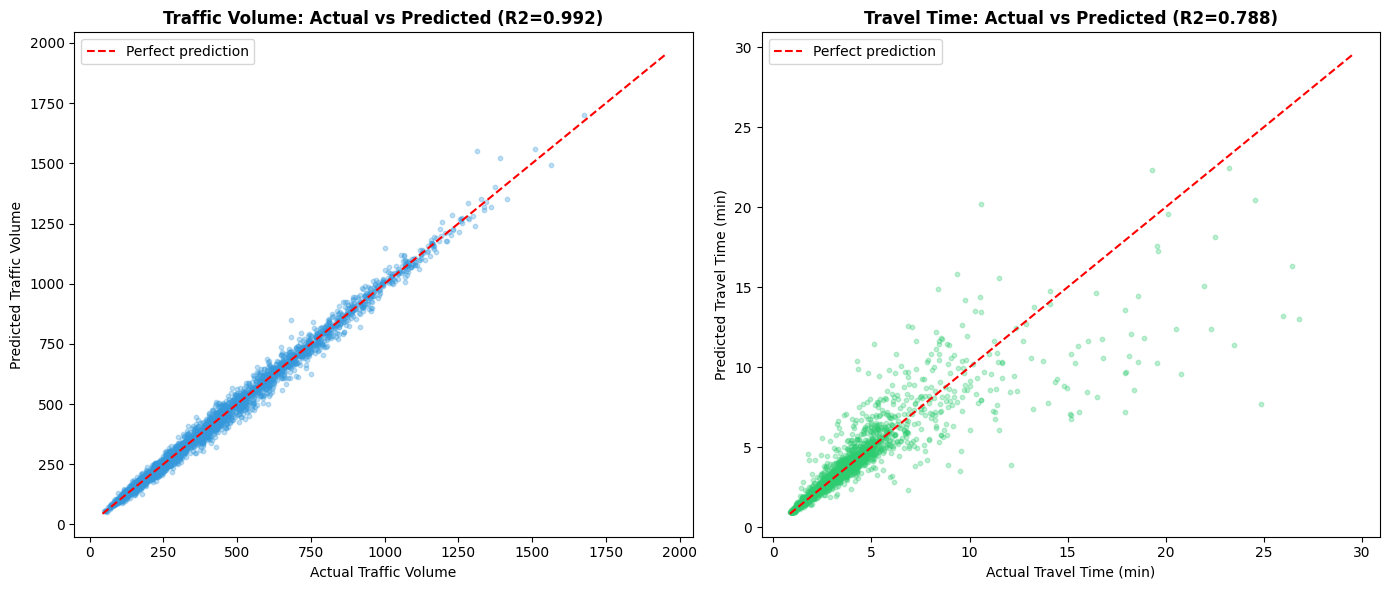

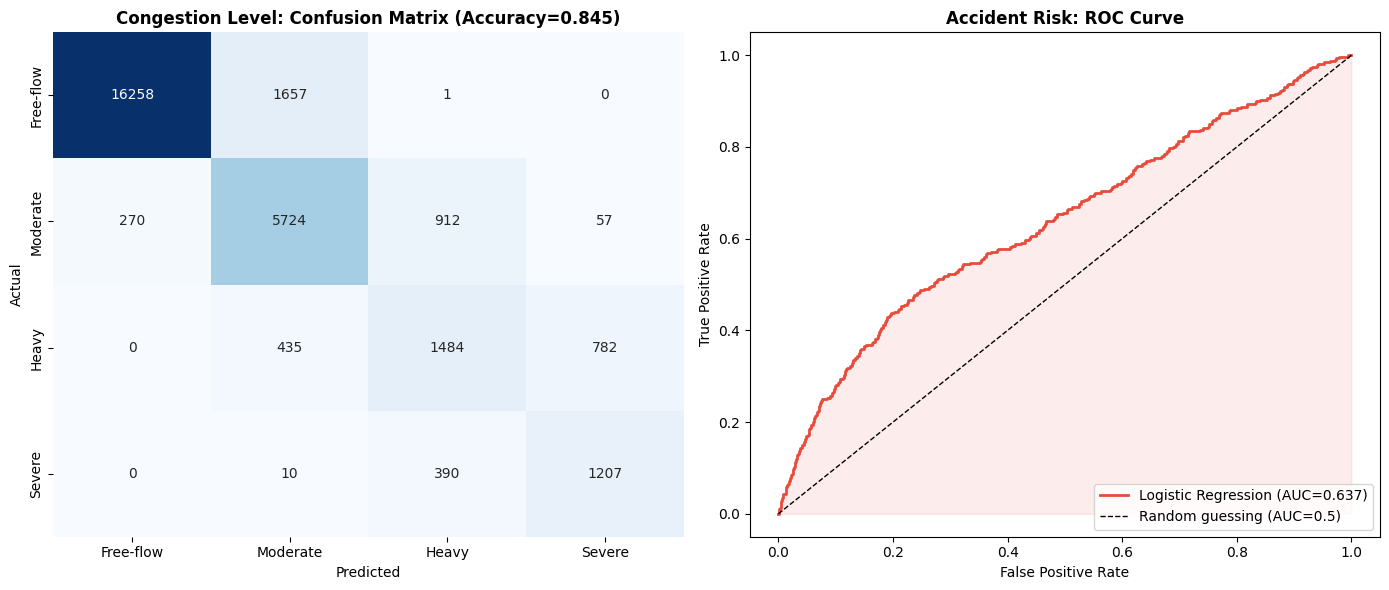

All evaluation charts saved: actual_vs_predicted.png, classification_eval.png


In [4]:
"""
Model Evaluation Charts for Traffic Analytics Platform
- Actual vs Predicted scatter plots (Volume, Travel Time - regression)
- Confusion matrix (Congestion Level - multi-class classification)
- ROC curve (Accident Risk - binary classification)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, roc_curve, roc_auc_score

traffic = pd.read_csv("traffic_merged.csv", low_memory=False)
traffic['date'] = pd.to_datetime(traffic['date'])
traffic['timestamp'] = pd.to_datetime(traffic['timestamp'])
traffic = traffic.sort_values(['road_id', 'timestamp']).reset_index(drop=True)
traffic['hour'] = traffic['timestamp'].dt.hour
traffic['day_of_week'] = traffic['timestamp'].dt.dayofweek
traffic['is_weekend'] = traffic['day_of_week'].isin([5, 6]).astype(int)
traffic['volume_lag1'] = traffic.groupby('road_id')['traffic_volume'].shift(1)
traffic['volume_lag2'] = traffic.groupby('road_id')['traffic_volume'].shift(2)
traffic['traveltime_lag1'] = traffic.groupby('road_id')['travel_time'].shift(1)
traffic['traveltime_lag2'] = traffic.groupby('road_id')['travel_time'].shift(2)
congestion_order = {'Free-flow': 0, 'Moderate': 1, 'Heavy': 2, 'Severe': 3}


# ===== MODEL 1: VOLUME =====
y1 = traffic['traffic_volume']
keep_cols_1 = ['latitude', 'longitude', 'avg_speed', 'occupancy', 'travel_time',
               'accident_count', 'signal_timing', 'road_capacity', 'hour', 'day_of_week', 'is_weekend',
               'weather_station_id', 'weather_condition', 'temperature', 'rainfall', 'visibility',
               'public_holiday', 'event_flag', 'roadwork_flag']
X1 = traffic[keep_cols_1].copy()
X1 = pd.get_dummies(X1, columns=['weather_station_id', 'weather_condition'], drop_first=True)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
model1 = RandomForestRegressor(n_estimators=80, max_depth=15, random_state=42, n_jobs=-1)
model1.fit(X1_train, y1_train)
pred1 = model1.predict(X1_test)
r2_1 = r2_score(y1_test, pred1)


# ===== MODEL 2: TRAVEL TIME (leakage-free, lagged features) =====
traffic_tt = traffic.dropna(subset=['volume_lag1','volume_lag2','traveltime_lag1','traveltime_lag2']).copy().reset_index(drop=True)
y2 = traffic_tt['travel_time']
keep_cols_2 = ['volume_lag1', 'volume_lag2', 'traveltime_lag1', 'traveltime_lag2',
               'signal_timing', 'road_capacity', 'hour', 'day_of_week', 'is_weekend',
               'latitude', 'longitude', 'weather_station_id', 'weather_condition',
               'temperature', 'rainfall', 'visibility', 'public_holiday', 'event_flag', 'roadwork_flag']
X2 = traffic_tt[keep_cols_2].copy()
X2 = pd.get_dummies(X2, columns=['weather_station_id', 'weather_condition'], drop_first=True)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
model2 = RandomForestRegressor(n_estimators=80, max_depth=15, random_state=42, n_jobs=-1)
model2.fit(X2_train, y2_train)
pred2 = model2.predict(X2_test)
r2_2 = r2_score(y2_test, pred2)


# ===== CHART 1: Actual vs Predicted (Volume + Travel Time) =====
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sample_idx = np.random.RandomState(42).choice(len(y1_test), min(3000, len(y1_test)), replace=False)
axes[0].scatter(y1_test.values[sample_idx], pred1[sample_idx], alpha=0.3, s=10, color='#3498DB')
lims = [min(y1_test.min(), pred1.min()), max(y1_test.max(), pred1.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Traffic Volume')
axes[0].set_ylabel('Predicted Traffic Volume')
axes[0].set_title(f'Traffic Volume: Actual vs Predicted (R2={r2_1:.3f})', fontweight='bold')
axes[0].legend()

sample_idx2 = np.random.RandomState(42).choice(len(y2_test), min(3000, len(y2_test)), replace=False)
axes[1].scatter(y2_test.values[sample_idx2], pred2[sample_idx2], alpha=0.3, s=10, color='#2ECC71')
lims2 = [min(y2_test.min(), pred2.min()), max(y2_test.max(), pred2.max())]
axes[1].plot(lims2, lims2, 'r--', linewidth=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual Travel Time (min)')
axes[1].set_ylabel('Predicted Travel Time (min)')
axes[1].set_title(f'Travel Time: Actual vs Predicted (R2={r2_2:.3f})', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


# ===== MODEL 3: CONGESTION =====
traffic_c = traffic[traffic['congestion_level'] != 'Unknown'].copy().dropna(subset=['volume_lag1','volume_lag2']).reset_index(drop=True)
y3 = traffic_c['congestion_level'].map(congestion_order)
keep_cols_3 = ['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
               'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude',
               'weather_station_id', 'weather_condition', 'temperature', 'rainfall', 'visibility',
               'public_holiday', 'event_flag', 'roadwork_flag']
X3 = traffic_c[keep_cols_3].copy()
X3 = pd.get_dummies(X3, columns=['weather_station_id', 'weather_condition'], drop_first=True)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)
model3 = RandomForestClassifier(n_estimators=80, max_depth=15, random_state=42, n_jobs=-1, class_weight='balanced')
model3.fit(X3_train, y3_train)
pred3 = model3.predict(X3_test)
acc3 = accuracy_score(y3_test, pred3)
cm = confusion_matrix(y3_test, pred3)


# ===== MODEL 4: ACCIDENT RISK =====
traffic_a = traffic.dropna(subset=['volume_lag1', 'volume_lag2']).copy().reset_index(drop=True)
y4 = (traffic_a['accident_count'] > 0).astype(int)
keep_cols_4 = ['volume_lag1', 'volume_lag2', 'signal_timing', 'road_capacity',
               'hour', 'day_of_week', 'is_weekend', 'latitude', 'longitude',
               'weather_station_id', 'weather_condition', 'temperature', 'rainfall', 'visibility',
               'public_holiday', 'event_flag', 'roadwork_flag']
X4 = traffic_a[keep_cols_4].copy()
X4 = pd.get_dummies(X4, columns=['weather_station_id', 'weather_condition'], drop_first=True)
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42, stratify=y4)
scaler = StandardScaler()
X4_train_s = scaler.fit_transform(X4_train)
X4_test_s = scaler.transform(X4_test)
model4 = LogisticRegression(max_iter=1000, class_weight='balanced', C=0.01)
model4.fit(X4_train_s, y4_train)
proba4 = model4.predict_proba(X4_test_s)[:, 1]
auc4 = roc_auc_score(y4_test, proba4)
fpr, tpr, _ = roc_curve(y4_test, proba4)


# ===== CHART 2: Confusion Matrix + ROC Curve =====
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

labels = ['Free-flow', 'Moderate', 'Heavy', 'Severe']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0], cbar=False)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Congestion Level: Confusion Matrix (Accuracy={acc3:.3f})', fontweight='bold')

axes[1].plot(fpr, tpr, color='#E74C3C', linewidth=2, label=f'Logistic Regression (AUC={auc4:.3f})')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Random guessing (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Accident Risk: ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')

plt.tight_layout()
plt.savefig('classification_eval.png', dpi=150, bbox_inches='tight')
plt.show()

print("All evaluation charts saved: actual_vs_predicted.png, classification_eval.png")